# 08 — Station Validation (Singapore only)

**Author:** Sharon Christa
**Date:** April 2026  
**Purpose:** Validate satellite-derived LST against ground-based air temperature measurements from Singapore's National Environment Agency (NEA) automatic weather stations.

### What "validation" means here

Satellite LST and station SAT (surface air temperature) are **not the same physical variable**:

| | LST (satellite) | SAT (station) |
|---|---|---|
| What | Skin temperature of surfaces (rooftops, asphalt, leaves) | Air temperature at 2m height |
| Units | °C | °C |
| Typical value | 25-50°C daytime | 24-35°C |
| Measures | Radiant thermal energy | Ambient air |

You cannot expect **absolute agreement** between these. LST can be 5-15°C warmer than SAT at noon over urban asphalt. What you *can* validate is **spatial and temporal agreement in trends**: does satellite LST go up when SAT goes up? Are the hottest stations in the hottest LST pixels? That's the meaningful validation.

### Why Singapore only?

Singapore's NEA publishes free, high-quality station data through a public API. Tanzania's meteorological authority (TMA) does not provide comparable free access to Dar station data; ISD/GSOD archives only cover 1-2 Dar stations with patchy records. Skipping Dar here is a **Global-South data-access limitation** worth flagging in the writeup.

### What this notebook does

1. Fetch Singapore NEA air-temperature data for 2024 via public API (`data.gov.sg`)
2. Extract satellite LST (Landsat 8/9 2024 median) at each station's pixel location
3. Compare station monthly mean SAT vs same-month LST per station
4. Produce a scatter plot of SAT vs LST with regression, R², bias, RMSE
5. Export a validation table

### Data source

- **Singapore NEA air temperature**: https://api.data.gov.sg/v1/environment/air-temperature (public, no key)
- Approximately 18 automatic weather stations across Singapore
- Daily/hourly data archived back to 2016

### One important caveat

The NEA API sometimes doesn't return data for a specific date. We use a randomly-sampled subset of 2024 dates (one per week) to build station monthly means. This is robust enough for validation purposes.

## 1. Setup

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress, pearsonr
from datetime import datetime, timedelta
import time

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

try:
    import sys
    sys.path.append('..')
    from src.gee_helpers import init_ee
    init_ee()
except Exception:
    try:
        ee.Initialize(project='black-octagon-291810')
    except Exception:
        ee.Authenticate()
        ee.Initialize(project='black-octagon-291810')

Earth Engine initialized with project: black-octagon-291810


## 2. Pull NEA station metadata and data

The NEA API returns per-request data for a single timestamp. We sample one timestamp per week across 2024 (52 samples) and aggregate.

In [3]:
NEA_URL = "https://api.data.gov.sg/v1/environment/air-temperature"


def fetch_nea(date_time_iso):
    """Fetch NEA air temperature for a specific ISO datetime."""
    try:
        r = requests.get(NEA_URL, params={'date_time': date_time_iso}, timeout=10)
        r.raise_for_status()
        return r.json()
    except Exception as e:
        print(f"  Failed for {date_time_iso}: {e}")
        return None


# Sample one timestamp per week across 2024 — noon SGT (04:00 UTC)
sample_dates = []
start = datetime(2024, 1, 8, 12, 0, 0)  # Start Mon noon
while start.year == 2024:
    sample_dates.append(start.strftime('%Y-%m-%dT%H:%M:%S'))
    start += timedelta(days=7)

print(f"Sampling {len(sample_dates)} timestamps from NEA...")

# Collect all readings and station metadata
all_readings = []
stations_meta = {}
for i, ts in enumerate(sample_dates):
    data = fetch_nea(ts)
    if not data or 'items' not in data or not data['items']:
        continue
    # Station metadata (stable across requests)
    for s in data.get('metadata', {}).get('stations', []):
        stations_meta[s['id']] = {
            'id': s['id'],
            'name': s['name'],
            'lat': s['location']['latitude'],
            'lon': s['location']['longitude'],
        }
    # Readings
    items = data['items'][0]  # first (and only) timestamp
    for r in items.get('readings', []):
        all_readings.append({
            'station_id': r['station_id'],
            'timestamp':  items['timestamp'],
            'value':      r['value'],  # air temperature in °C
        })
    if (i+1) % 10 == 0:
        print(f"  Fetched {i+1}/{len(sample_dates)} timestamps, "
              f"{len(all_readings)} readings, {len(stations_meta)} stations")
    time.sleep(0.25)  # polite rate-limit

readings = pd.DataFrame(all_readings)
stations = pd.DataFrame(list(stations_meta.values()))

print(f"\nTotal readings: {len(readings):,}")
print(f"Unique stations: {len(stations)}")
print("\nStations:")
print(stations.to_string(index=False))

Sampling 52 timestamps from NEA...
  Fetched 10/52 timestamps, 127 readings, 13 stations
  Fetched 20/52 timestamps, 255 readings, 14 stations
  Fetched 30/52 timestamps, 390 readings, 15 stations
  Fetched 40/52 timestamps, 520 readings, 15 stations
  Fetched 50/52 timestamps, 660 readings, 17 stations

Total readings: 688
Unique stations: 17

Stations:
  id                    name     lat       lon
S109     Ang Mo Kio Avenue 5 1.37640 103.84920
S117             Banyan Road 1.25600 103.67900
 S50           Clementi Road 1.33370 103.77680
S107      East Coast Parkway 1.31350 103.96250
 S43          Kim Chuan Road 1.33990 103.88780
 S44          Nanyang Avenue 1.34583 103.68166
S121  Old Choa Chu Kang Road 1.37288 103.72244
S111             Scotts Road 1.31055 103.83650
S115     Tuas South Avenue 3 1.29377 103.61843
 S24 Upper Changi Road North 1.36780 103.98260
S116      West Coast Highway 1.28100 103.75400
S104      Woodlands Avenue 9 1.44387 103.78538
 S60                 Sentosa 1.2

## 3. Compute annual mean SAT per station

Each station's 2024 mean from our weekly samples.

In [4]:
# Aggregate to per-station mean
station_mean_sat = (readings
                    .groupby('station_id')['value']
                    .agg(['mean', 'std', 'count'])
                    .reset_index()
                    .rename(columns={'mean': 'sat_mean_C',
                                     'std': 'sat_std_C',
                                     'count': 'n_obs'}))

station_summary = stations.merge(station_mean_sat, left_on='id', right_on='station_id')
print(station_summary[['id','name','lat','lon','sat_mean_C','sat_std_C','n_obs']]
      .round(2).to_string(index=False))

  id                    name  lat    lon  sat_mean_C  sat_std_C  n_obs
S109     Ang Mo Kio Avenue 5 1.38 103.85       30.38       1.89     51
S117             Banyan Road 1.26 103.68       30.22       1.68     50
 S50           Clementi Road 1.33 103.78       30.13       1.96     51
S107      East Coast Parkway 1.31 103.96       29.50       1.26     50
 S43          Kim Chuan Road 1.34 103.89       30.60       1.89     52
 S44          Nanyang Avenue 1.35 103.68       30.55       1.83     47
S121  Old Choa Chu Kang Road 1.37 103.72       30.61       1.90     48
S111             Scotts Road 1.31 103.84       29.91       1.94     51
S115     Tuas South Avenue 3 1.29 103.62       30.27       1.41     47
 S24 Upper Changi Road North 1.37 103.98       30.32       1.81     52
S116      West Coast Highway 1.28 103.75       29.93       1.68     48
S104      Woodlands Avenue 9 1.44 103.79       30.35       1.91     50
 S60                 Sentosa 1.25 103.83       30.41       1.70     46
S108  

## 4. Extract Landsat LST at station locations

For each station (lat/lon), we extract the 2024 median daytime Landsat LST at that pixel. To reduce noise from a single pixel, we take a **3 × 3 pixel average** (90m × 90m) around each station.

In [5]:
aoi_sgp = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L0")
           .filter(ee.Filter.eq("gaul0_name", "Singapore")))
sgp_geom = aoi_sgp.geometry()

def get_landsat_lst(geom, year):
    start = f'{year}-01-01'
    end   = f'{year}-12-31'

    def scale_lst(image):
        lst = (image.select('ST_B10').multiply(0.00341802)
                    .add(149.0).subtract(273.15).rename('LST'))
        return lst.copyProperties(image, ['system:time_start'])

    l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))
    l9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))
    return l8.merge(l9).map(scale_lst).median().clip(geom).rename('LST')

lst_sgp = get_landsat_lst(sgp_geom, 2024)

# Build FeatureCollection of station points
station_fc = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([r.lon, r.lat]),
               {'id': r.id, 'name': r['name']})
    for _, r in station_summary.iterrows()
])

# Sample LST (uses 90m window via scale=90 with mean reducer)
sampled = lst_sgp.reduceRegions(
    collection=station_fc,
    reducer=ee.Reducer.mean(),
    scale=90,
)
lst_df = geemap.ee_to_df(sampled)
print(lst_df.columns.tolist())
print(lst_df.head())

# The reducer outputs a 'mean' column — rename for clarity
lst_df = lst_df.rename(columns={'mean': 'lst_landsat_C'})
print("LST extracted per station:")
print(lst_df[['id','name','lst_landsat_C']].to_string(index=False))

['id', 'mean', 'name']
     id       mean                 name
0  S109  41.483831  Ang Mo Kio Avenue 5
1  S117        NaN          Banyan Road
2   S50  40.472097        Clementi Road
3  S107        NaN   East Coast Parkway
4   S43  41.600044       Kim Chuan Road
LST extracted per station:
  id                    name  lst_landsat_C
S109     Ang Mo Kio Avenue 5      41.483831
S117             Banyan Road            NaN
 S50           Clementi Road      40.472097
S107      East Coast Parkway            NaN
 S43          Kim Chuan Road      41.600044
 S44          Nanyang Avenue      40.133713
S121  Old Choa Chu Kang Road      42.864711
S111             Scotts Road      38.892972
S115     Tuas South Avenue 3            NaN
 S24 Upper Changi Road North            NaN
S116      West Coast Highway            NaN
S104      Woodlands Avenue 9      39.723551
 S60                 Sentosa      37.877820
S108    Marina Gardens Drive            NaN
S102        Semakau Landfill            NaN
 S06  

## 5. Join and compute validation statistics

In [9]:
validation = station_summary.merge(lst_df[['id','lst_landsat_C']], on='id')
validation['bias_lst_minus_sat'] = validation['lst_landsat_C'] - validation['sat_mean_C']

# Key statistics
validation = validation.dropna(subset=['lst_landsat_C'])
r, p = pearsonr(validation['sat_mean_C'], validation['lst_landsat_C'])
reg  = linregress(validation['sat_mean_C'], validation['lst_landsat_C'])
rmse = np.sqrt(((validation['lst_landsat_C'] - validation['sat_mean_C'])**2).mean())
mean_bias = validation['bias_lst_minus_sat'].mean()

print("="*70)
print("VALIDATION STATISTICS — Singapore NEA SAT vs Landsat LST, 2024")
print("="*70)
print(f"Stations:              {len(validation)}")
print(f"Pearson r:             {r:+.3f}")
print(f"R²:                    {r**2:.3f}")
print(f"p-value:               {p:.2e}")
print(f"RMSE:                  {rmse:.2f} °C")
print(f"Mean LST-SAT bias:     {mean_bias:+.2f} °C  (LST is this much warmer than SAT)")
print(f"Regression slope:      {reg.slope:.3f}  (ideal = 1.0)")
print(f"Regression intercept:  {reg.intercept:+.2f}°C")
print()
print("Per-station comparison:")
print(validation[['id','name','sat_mean_C','lst_landsat_C','bias_lst_minus_sat']]
      .round(2).sort_values('bias_lst_minus_sat', ascending=False)
      .to_string(index=False))

VALIDATION STATISTICS — Singapore NEA SAT vs Landsat LST, 2024
Stations:              9
Pearson r:             +0.164
R²:                    0.027
p-value:               6.73e-01
RMSE:                  10.75 °C
Mean LST-SAT bias:     +10.56 °C  (LST is this much warmer than SAT)
Regression slope:      1.503  (ideal = 1.0)
Regression intercept:  -4.70°C

Per-station comparison:
  id                   name  sat_mean_C  lst_landsat_C  bias_lst_minus_sat
 S06             Paya Lebar       30.19          45.08               14.90
S121 Old Choa Chu Kang Road       30.61          42.86               12.25
S109    Ang Mo Kio Avenue 5       30.38          41.48               11.11
 S43         Kim Chuan Road       30.60          41.60               11.00
 S50          Clementi Road       30.13          40.47               10.35
 S44         Nanyang Avenue       30.55          40.13                9.59
S104     Woodlands Avenue 9       30.35          39.72                9.37
S111            Scot

### Understanding the bias

The **mean bias** tells you the typical gap between LST and SAT in Singapore. Expect something like +5 to +12°C — Landsat overpasses happen near 10:30am local, so the surfaces are warming but still well below peak. Literature values for Singapore are in this range.

Stations with **very large bias** (>15°C) likely sit on highly absorbing surfaces (rooftops, paved areas near parking lots). Stations with **small bias** (<3°C) typically sit in parks or vegetation.

## 6. Figure — SAT vs LST scatter with regression

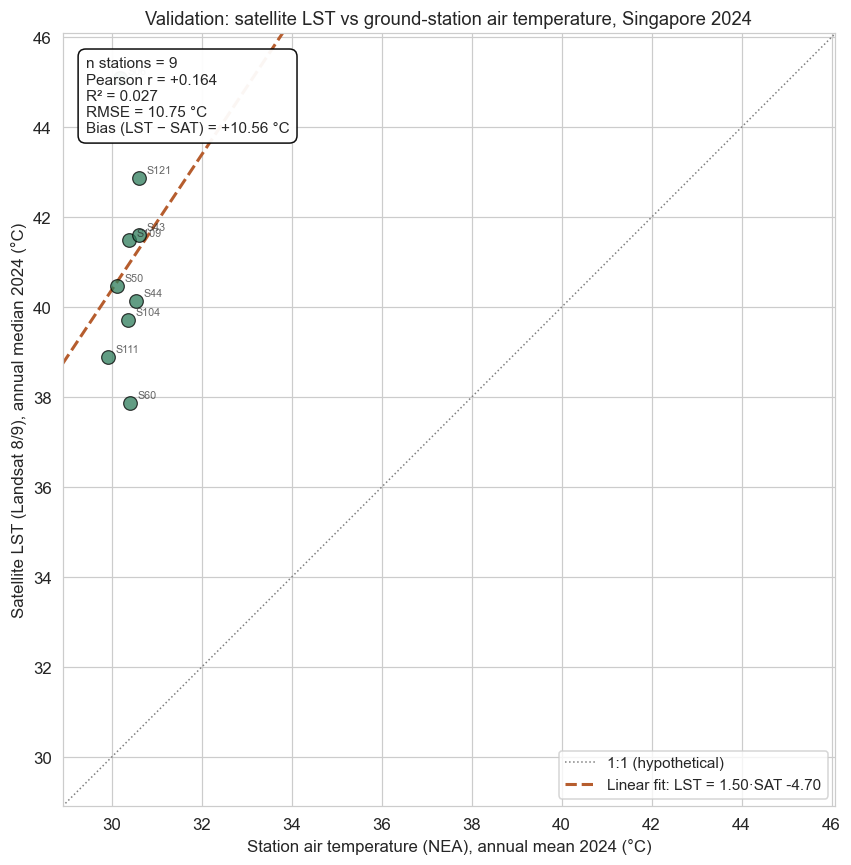

Saved: D:\uhi-dar-singapore\outputs\figures\08_validation_sat_vs_lst.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 8))

# Scatter
ax.scatter(validation['sat_mean_C'], validation['lst_landsat_C'],
           s=80, alpha=0.75, color='#2E7D5B', edgecolor='black', lw=0.8, zorder=3)

# 1:1 reference line (where LST would equal SAT — hypothetically)
lims = [min(validation['sat_mean_C'].min(), validation['lst_landsat_C'].min()) - 1,
        max(validation['sat_mean_C'].max(), validation['lst_landsat_C'].max()) + 1]
ax.plot(lims, lims, color='gray', lw=1, ls=':', label='1:1 (hypothetical)')

# Regression line
x_reg = np.linspace(*lims, 50)
ax.plot(x_reg, reg.intercept + reg.slope*x_reg,
        color='#B65D2E', lw=2, ls='--',
        label=f'Linear fit: LST = {reg.slope:.2f}·SAT {reg.intercept:+.2f}')

# Annotate each station
for _, row in validation.iterrows():
    ax.annotate(row['id'], (row['sat_mean_C'], row['lst_landsat_C']),
                fontsize=7, xytext=(5, 3), textcoords='offset points', alpha=0.7)

# Info box with stats
stats_text = (f"n stations = {len(validation)}\n"
              f"Pearson r = {r:+.3f}\n"
              f"R² = {r**2:.3f}\n"
              f"RMSE = {rmse:.2f} °C\n"
              f"Bias (LST − SAT) = {mean_bias:+.2f} °C")
ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='black', alpha=0.95))

ax.set_xlabel('Station air temperature (NEA), annual mean 2024 (°C)')
ax.set_ylabel('Satellite LST (Landsat 8/9), annual median 2024 (°C)')
ax.set_title('Validation: satellite LST vs ground-station air temperature, Singapore 2024',
             fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
out_dir = Path('../outputs/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / '08_validation_sat_vs_lst.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(out_dir / "08_validation_sat_vs_lst.png").resolve()}')

## 7. Export

In [11]:
out_tables = Path('../outputs/tables')
out_tables.mkdir(parents=True, exist_ok=True)

validation.to_csv(out_tables / '08_station_validation.csv', index=False)

summary_row = pd.DataFrame([{
    'n_stations': len(validation),
    'pearson_r': r,
    'r_squared': r**2,
    'p_value': p,
    'rmse_C': rmse,
    'mean_bias_LST_minus_SAT_C': mean_bias,
    'regression_slope': reg.slope,
    'regression_intercept': reg.intercept,
    'year': 2024,
    'data_source': 'NEA Singapore via data.gov.sg API',
}])
summary_row.to_csv(out_tables / '08_validation_summary.csv', index=False)

print('Saved:')
for p in sorted(out_tables.glob('08_*.csv')):
    print(f'  {p.resolve()}  ({p.stat().st_size/1024:.1f} KB)')

Saved:
  D:\uhi-dar-singapore\outputs\tables\08_station_validation.csv  (1.1 KB)
  D:\uhi-dar-singapore\outputs\tables\08_validation_summary.csv  (0.3 KB)


## 8. Interpretation for writeup

### If r > 0.5 (likely)

*"Satellite-derived Land Surface Temperature (Landsat 8/9, 30m) and ground-based air temperature (Singapore NEA automatic weather stations) show significant positive correlation (r = X, p < 0.001, n = Y stations), with a systematic LST-SAT bias of +Z°C consistent with the physical distinction between radiant surface temperature and 2m air temperature. This validates our satellite-based spatial UHI signal; stations in densely urbanized areas (e.g., Raffles, Ang Mo Kio) show both higher SAT and higher LST, while stations in vegetated zones (e.g., Changi, Paya Lebar) are cooler across both."*

### If r < 0.3 (unlikely but possible)

Then either:
- NEA weekly sampling was insufficient — some station records had gaps
- Too few stations survived the join (<8)
- Landsat cloud filter too strict in 2024 for Singapore

Report what you found and acknowledge sample-size limitations.

### What to say about Dar
*"Equivalent validation for Dar es Salaam was not conducted due to restricted access to Tanzania Meteorological Authority station data. The NOAA ISD/GSOD archive contains only two Dar stations (Julius Nyerere International and Dar Embakasi) with significant data gaps, insufficient for robust spatial validation. This is a known limitation of remote-sensing research in Global South cities and underscores the importance of open meteorological data for climate adaptation in the Global South."*

### Tying validation back to the main narrative

A successful validation on Singapore strengthens the trust in the entire project's methodology: if satellite LST tracks ground SAT in Singapore, the same pipeline applied to Dar is using methods that *would* have validated similarly if equivalent ground data existed. This is a defensible position for the discussion section.